# Day 1-1: 환경 설정 & MLflow 세팅

**강의 시간**: 1시간  
**학습 목표**:
- Google Colab Pro 환경 설정
- Dagshub 계정 생성 및 프로젝트 설정
- MLflow 연동 및 첫 실험 로깅
- Dacon 데이터 다운로드

## 1️⃣ Google Colab 환경 확인



### GPU 확인하기

먼저 GPU가 할당되어 있는지 확인합니다.

💡 **실행 방법**: Shift + Enter 또는 ▶️ 버튼 클릭

In [ ]:
# GPU 확인
import torch

if torch.cuda.is_available():
    print("✅ GPU 사용 가능!")
    print(f"GPU 이름: {torch.cuda.get_device_name(0)}")
    print(f"GPU 메모리: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("❌ GPU 사용 불가 - CPU 모드")
    print("⚠️ 런타임 > 런타임 유형 변경 > GPU(T4) 선택")

✅ GPU 사용 가능!
GPU 이름: NVIDIA GeForce RTX 3090
GPU 메모리: 25.29 GB


### Google Drive 연동

실험 결과와 데이터를 저장하기 위해 Google Drive를 연결합니다.

🔐 **실행하면 인증 링크가 나타납니다. 클릭해서 권한을 승인하세요.**

In [ ]:
# from google.colab import drive

# # Google Drive 마운트
# drive.mount('/content/drive')

# print("\n✅ Google Drive 연결 완료!")
# print("📁 Drive 경로: /content/drive/MyDrive")

### 작업 폴더 생성

부트캠프 전용 폴더를 만들어서 정리합니다.

In [ ]:
# import os

# # 폴더 구조 생성
# # base_path = '/content/drive/MyDrive/deeplearning-bootcamp'
# base_path = '/content/drive/MyDrive/lectures/dl_bootcamp'
# day1_path = os.path.join(base_path, 'day1_news_classification')
# data_path = os.path.join(day1_path, 'data')

# os.makedirs(data_path, exist_ok=True)

# print("✅ 폴더 생성 완료!")
# print(f"📁 Base: {base_path}")
# print(f"📁 Day 1: {day1_path}")
# print(f"📁 Data: {data_path}")

## 2️⃣ Dagshub & MLflow 설정



### 필수 라이브러리 설치

In [ ]:
# 라이브러리 설치 (약 30초 소요)
%pip install -q dagshub 'mlflow>=2,<3'

print("✅ 라이브러리 설치 완료!")

✅ 라이브러리 설치 완료!


### Dagshub 프로젝트 연동

⚠️ **중요**: 아래 코드의 `repo_owner`와 `repo_name`을 본인의 Dagshub 정보로 바꾸세요!

**Dagshub 계정 생성 방법**:
1. https://dagshub.com 접속
2. GitHub 또는 Google 계정으로 로그인
3. `Create +` > `New Repository` 클릭
4. Repository name: `deeplearning-bootcamp` (또는 원하는 이름)
5. Public 선택 후 생성

**정보 확인**:
- Repository Owner: Dagshub의 username (예: `hong-gildong`)
- Repository Name: 생성한 repo 이름 (예: `deeplearning-bootcamp`)

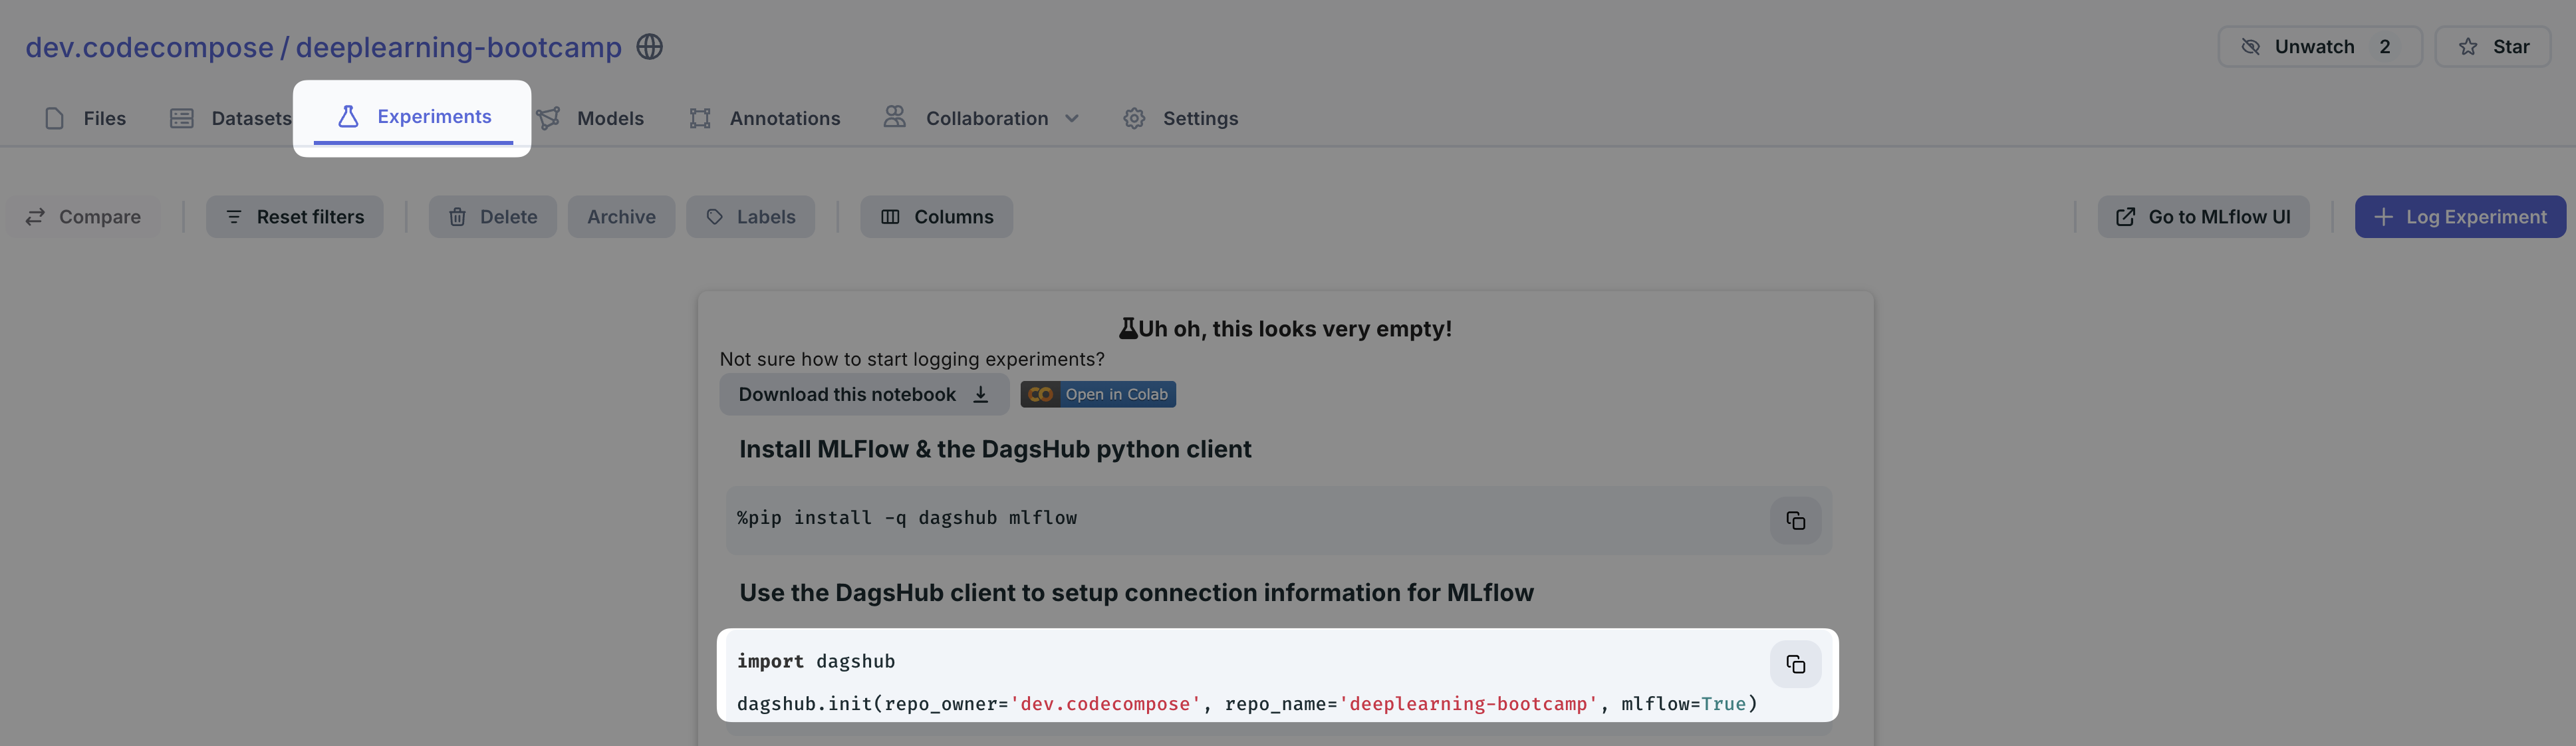

In [ ]:
import dagshub

# 🔥 여기를 수정하세요!
repo_owner = 'dev.codecompose'  # 본인의 Dagshub username
repo_name = 'deeplearning-bootcamp'  # 생성한 repository 이름 (예: deeplearning-bootcamp)

dagshub.init(
    repo_owner=repo_owner,
    repo_name=repo_name,
    mlflow=True
)

print("✅ Dagshub 연동 완료!")
print(f"🌐 Dagshub UI: https://dagshub.com/{repo_owner}/{repo_name}")

Initialized MLflow to track repo "dev.codecompose/deeplearning-bootcamp"

Repository dev.codecompose/deeplearning-bootcamp initialized!

✅ Dagshub 연동 완료!
🌐 Dagshub UI: https://dagshub.com/dev.codecompose/deeplearning-bootcamp


## 3️⃣ MLflow 첫 실험 로깅 테스트


### 간단한 테스트 실험

In [ ]:
import mlflow

# 첫 번째 실험!
with mlflow.start_run(run_name="test_connection"):
    # 파라미터 로깅
    mlflow.log_param('test_param', 'hello_mlflow')

    # 메트릭 로깅
    mlflow.log_metric('test_accuracy', 0.99)

    print("✅ 첫 MLflow 실험 기록 완료!")
    print("🔍 Dagshub에서 확인해보세요!")

✅ 첫 MLflow 실험 기록 완료!
🔍 Dagshub에서 확인해보세요!
🏃 View run test_connection at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/0/runs/c17c487eb0aa44e6935b021135ace442
🧪 View experiment at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/0


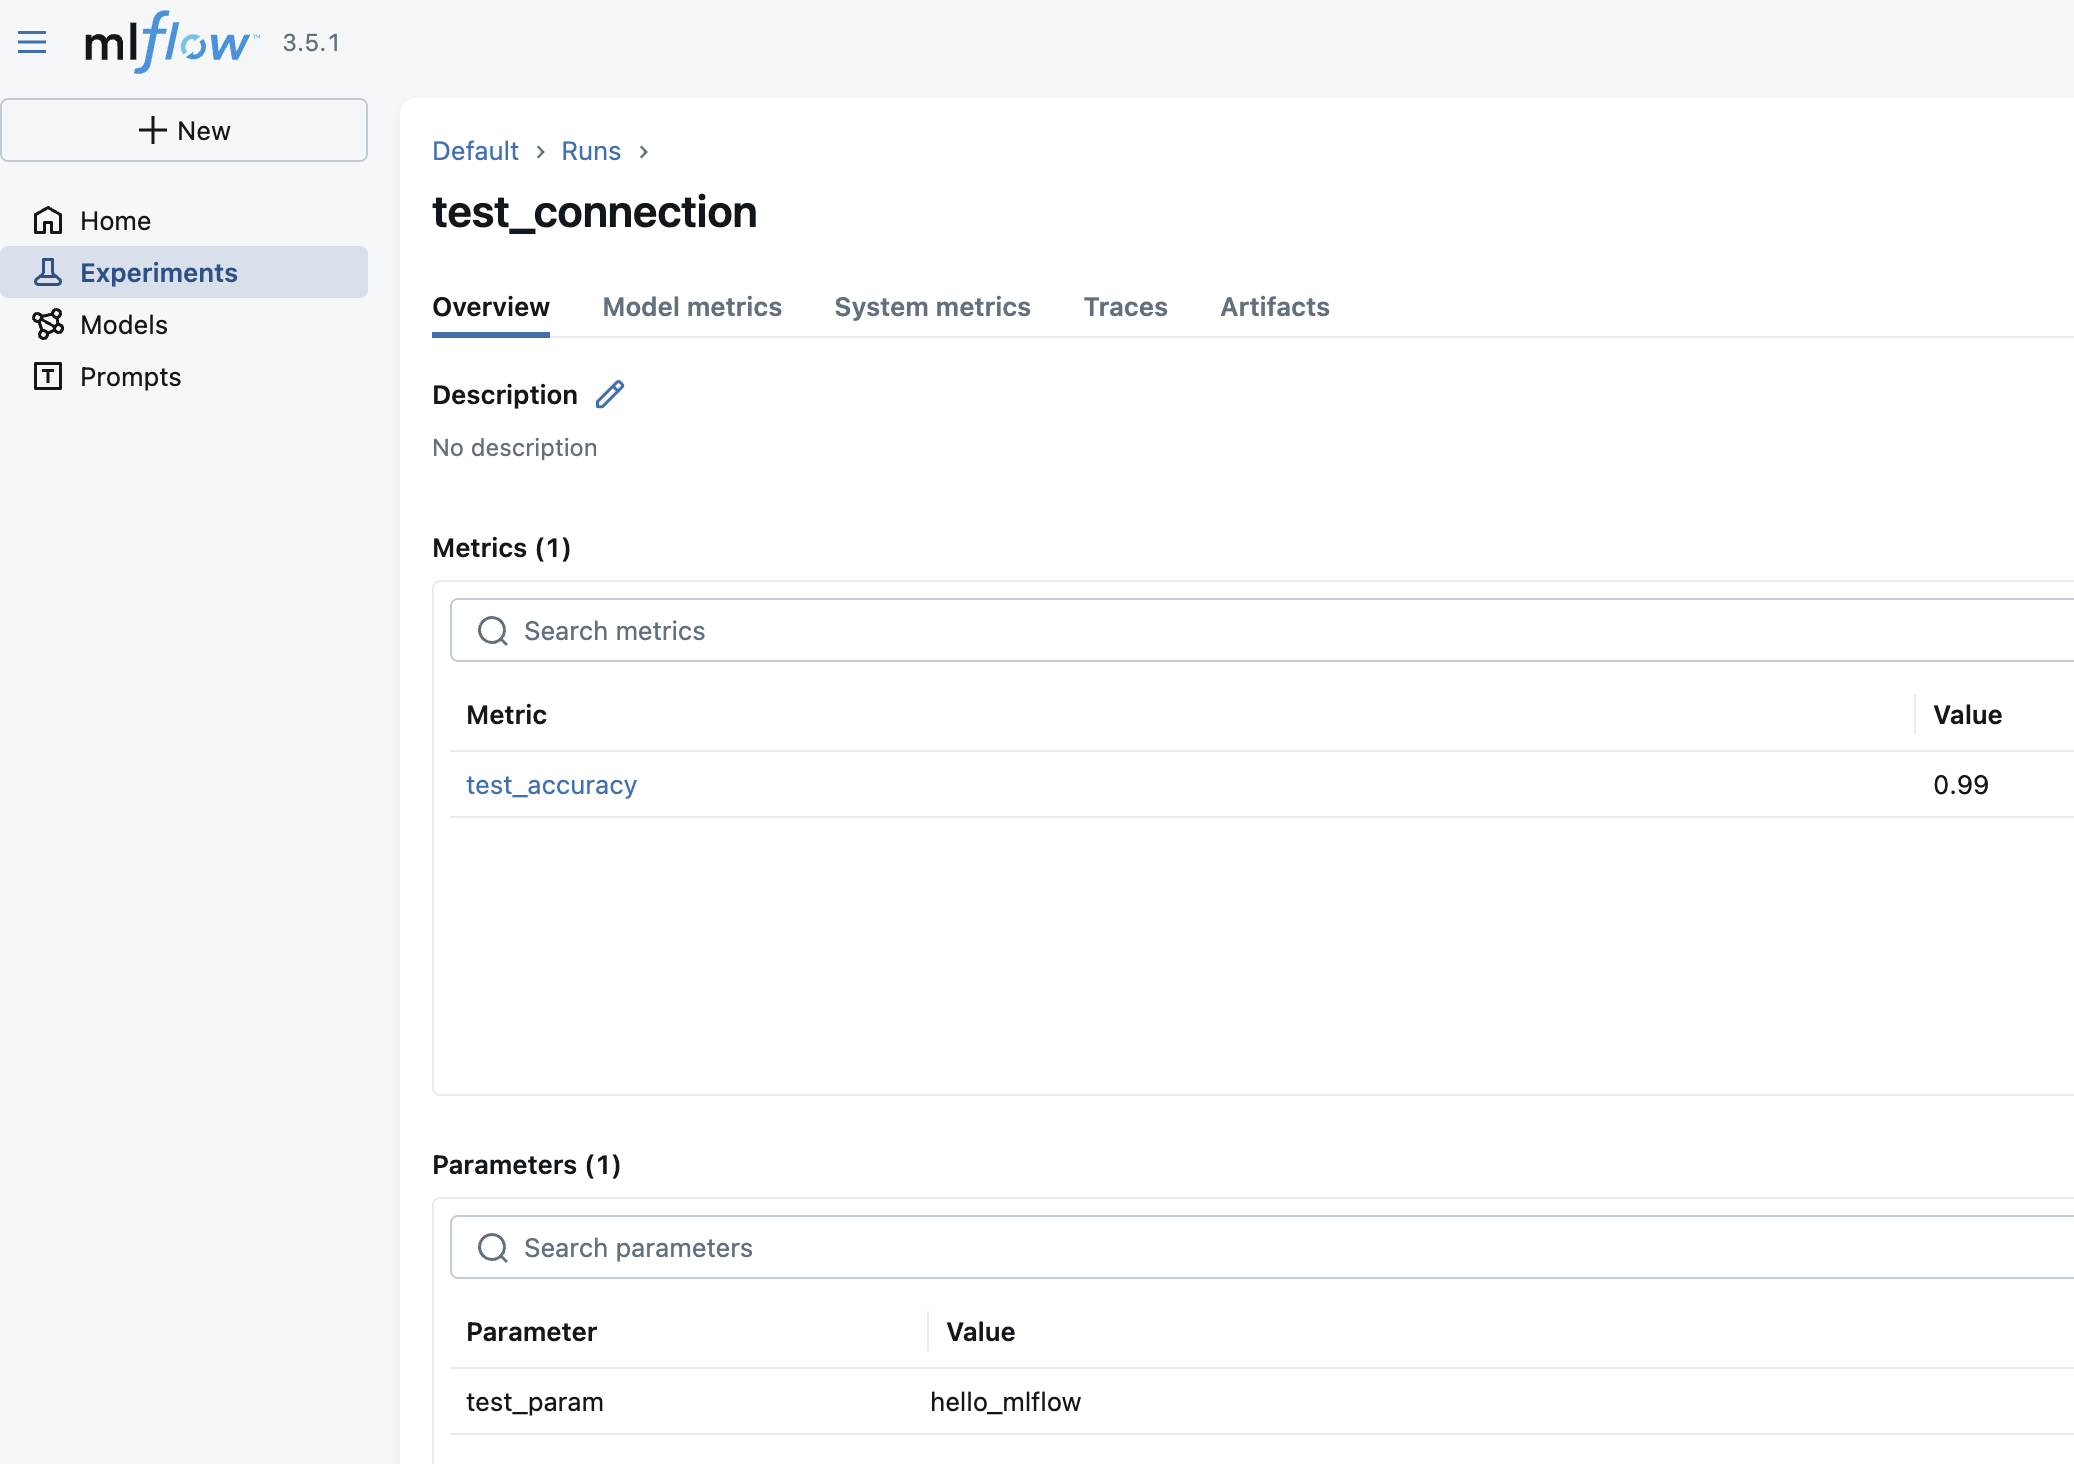

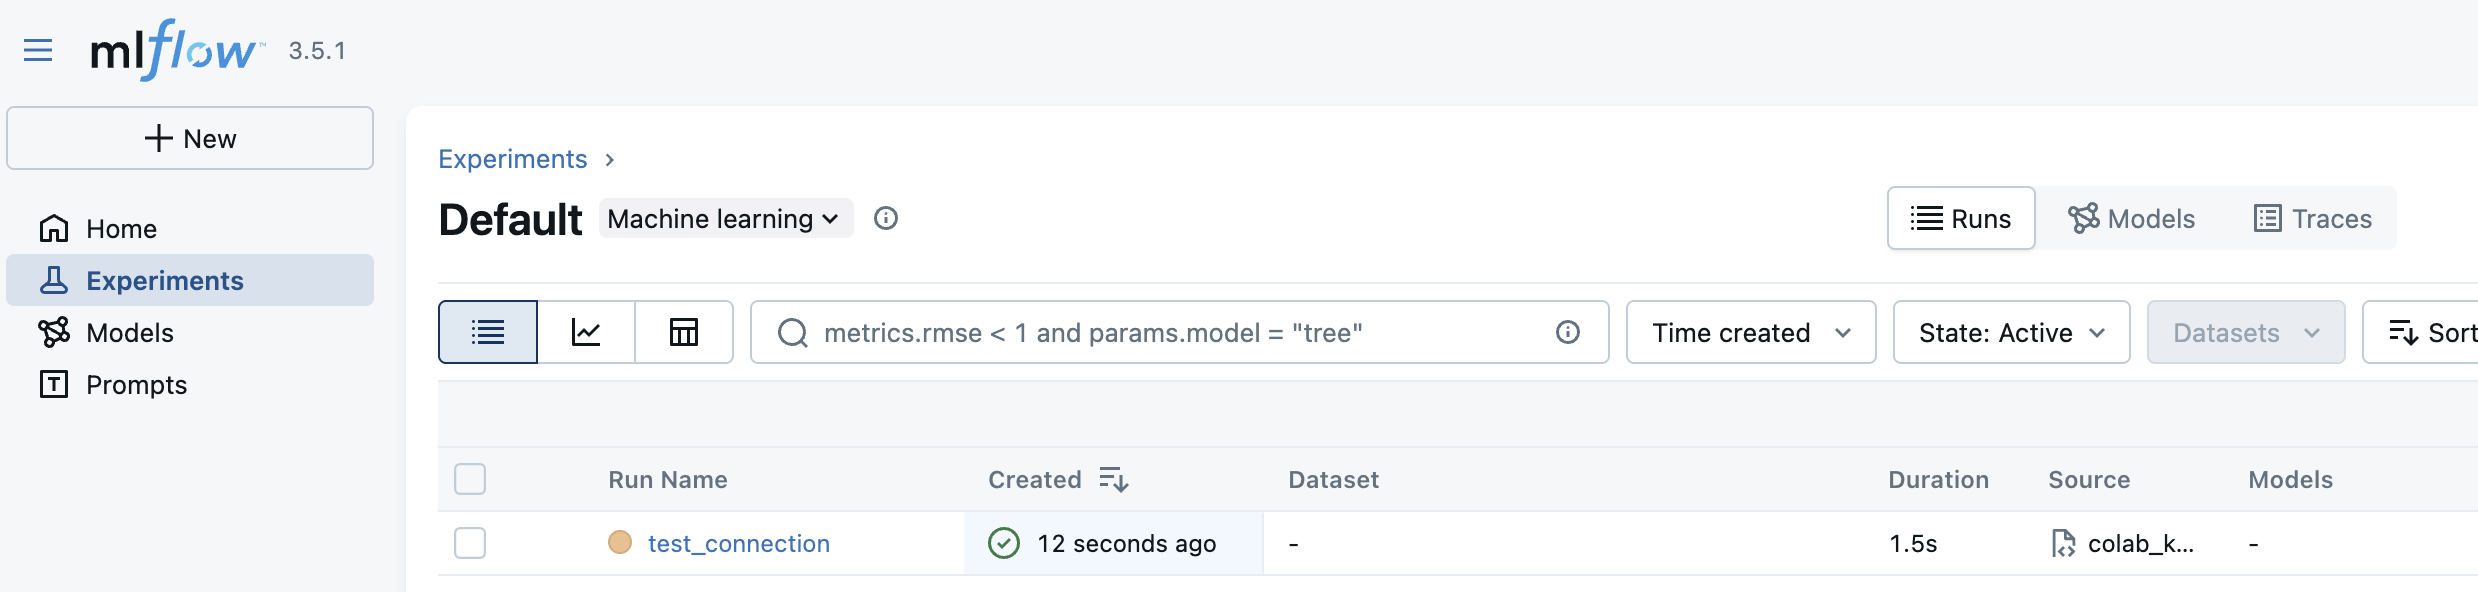

### 여러 실험 시뮬레이션

실제 실험처럼 여러 개의 run을 생성해봅니다.

In [ ]:
import random

# 5개의 가상 실험 실행
for i in range(5):
    with mlflow.start_run(run_name=f"experiment_{i+1}"):
        # 하이퍼파라미터 (랜덤)
        lr = random.choice([0.001, 0.01, 0.1])
        batch_size = random.choice([16, 32, 64])

        mlflow.log_param('learning_rate', lr)
        mlflow.log_param('batch_size', batch_size)

        # 가상 결과 (실제로는 모델 학습 후 기록)
        accuracy = random.uniform(0.7, 0.95)
        loss = random.uniform(0.1, 0.5)

        mlflow.log_metric('accuracy', accuracy)
        mlflow.log_metric('loss', loss)

        print(f"✅ Exp {i+1} - LR: {lr}, Batch: {batch_size}, Acc: {accuracy:.3f}")

print("\n🎉 5개 실험 기록 완료!")

✅ Exp 1 - LR: 0.01, Batch: 32, Acc: 0.948
🏃 View run experiment_1 at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/0/runs/9a80be6fe67c47a58a50a916e31c02e1
🧪 View experiment at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/0
✅ Exp 2 - LR: 0.1, Batch: 16, Acc: 0.734
🏃 View run experiment_2 at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/0/runs/6b94d57e3959420abb6cfe36c51edede
🧪 View experiment at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/0
✅ Exp 3 - LR: 0.01, Batch: 32, Acc: 0.802
🏃 View run experiment_3 at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/0/runs/733343363c2c4cf68850b08bda4e5ab9
🧪 View experiment at: https://dagshub.com/dev.codecompose/deeplearning-bootcamp.mlflow/#/experiments/0
✅ Exp 4 - LR: 0.01, Batch: 16, Acc: 0.876
🏃 View run experiment_4 at: https://dagshub.com/dev.codecompose/deeplearning-bootca

### 📊 Dagshub UI에서 확인하기

1. Dagshub 프로젝트 페이지로 이동
2. 좌측 메뉴 "Experiments" 클릭
3. 방금 기록한 6개 실험 확인
4. 각 실험을 클릭해서 Parameters, Metrics 확인

**비교하기**:
- 여러 실험 체크박스 선택
- "Compare" 버튼 클릭
- Parallel Coordinates Plot으로 시각화

---

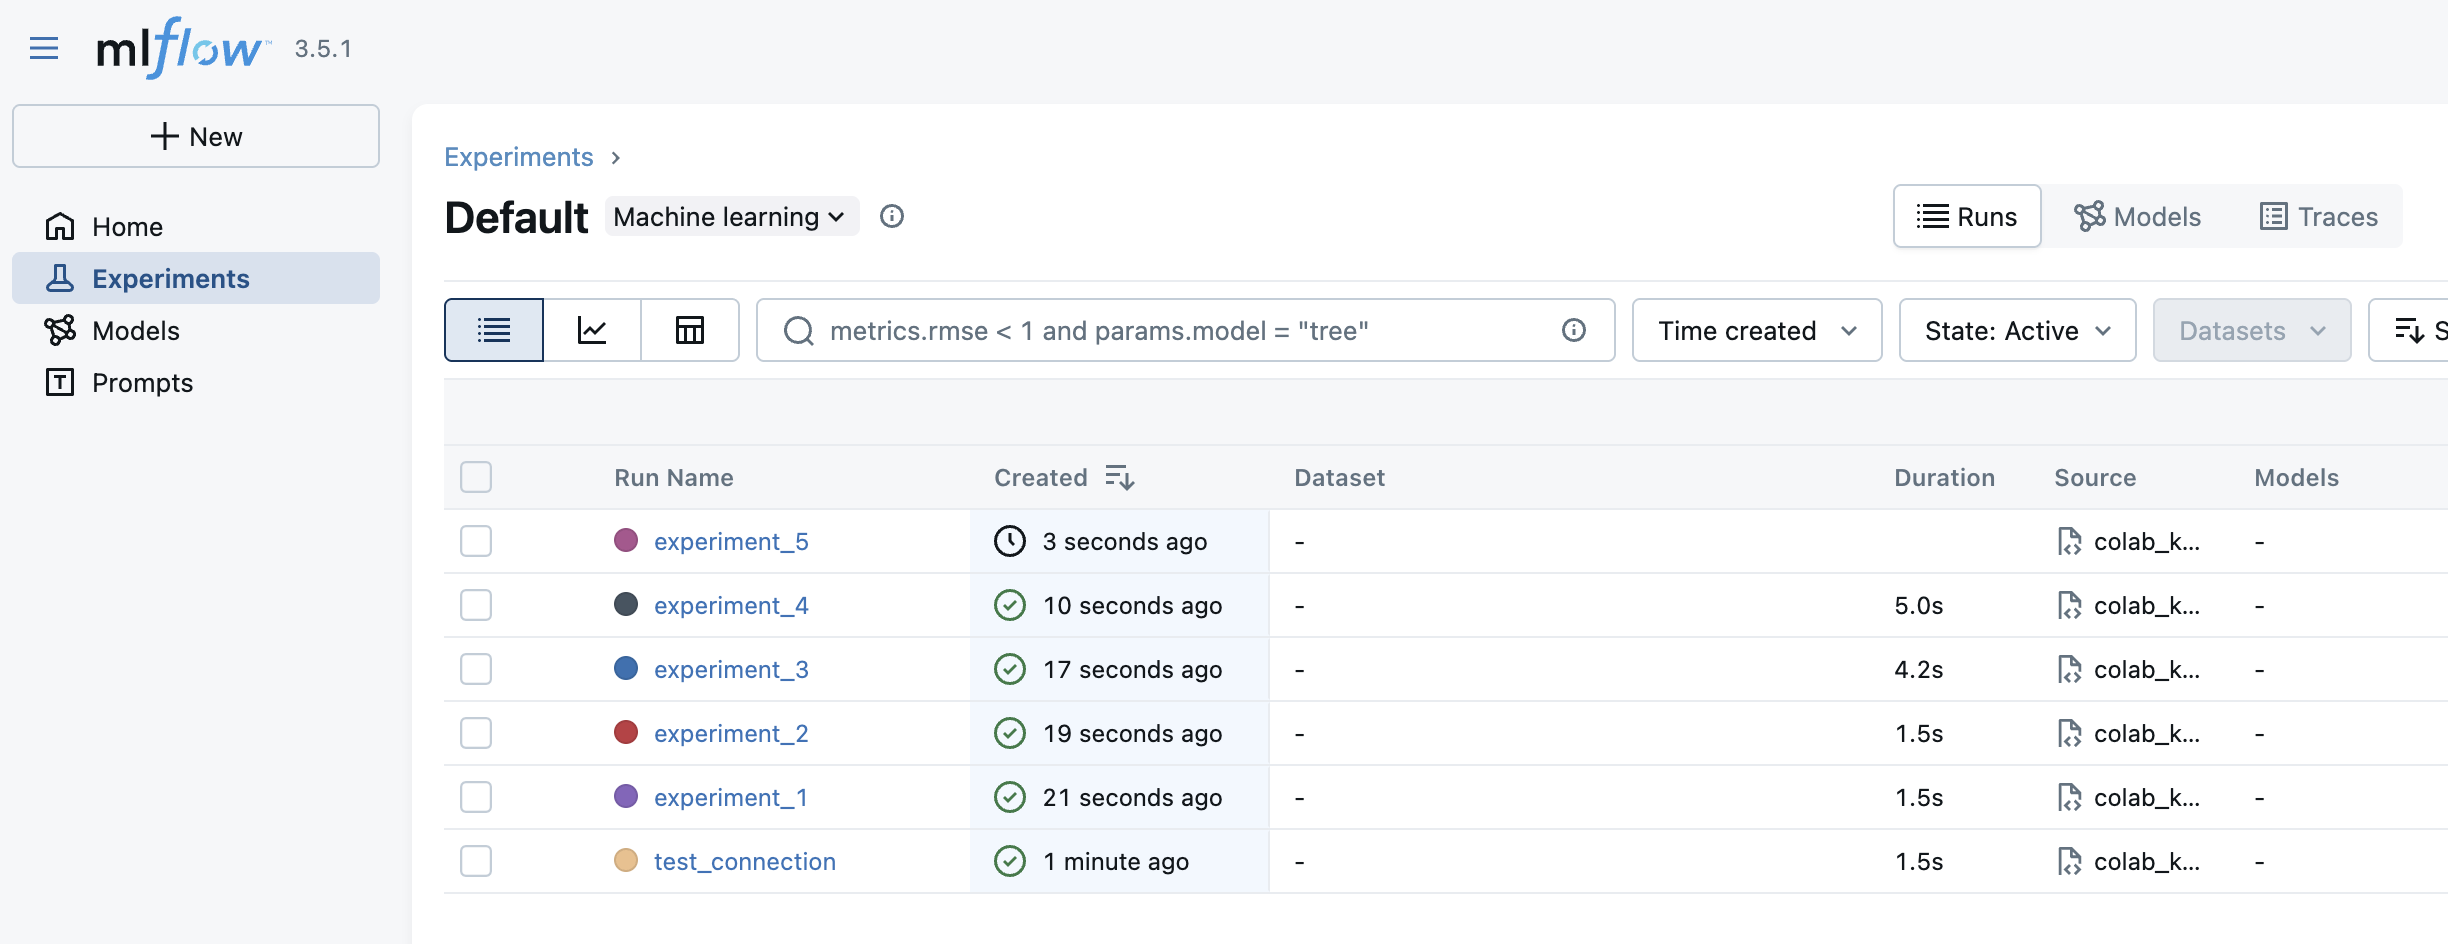

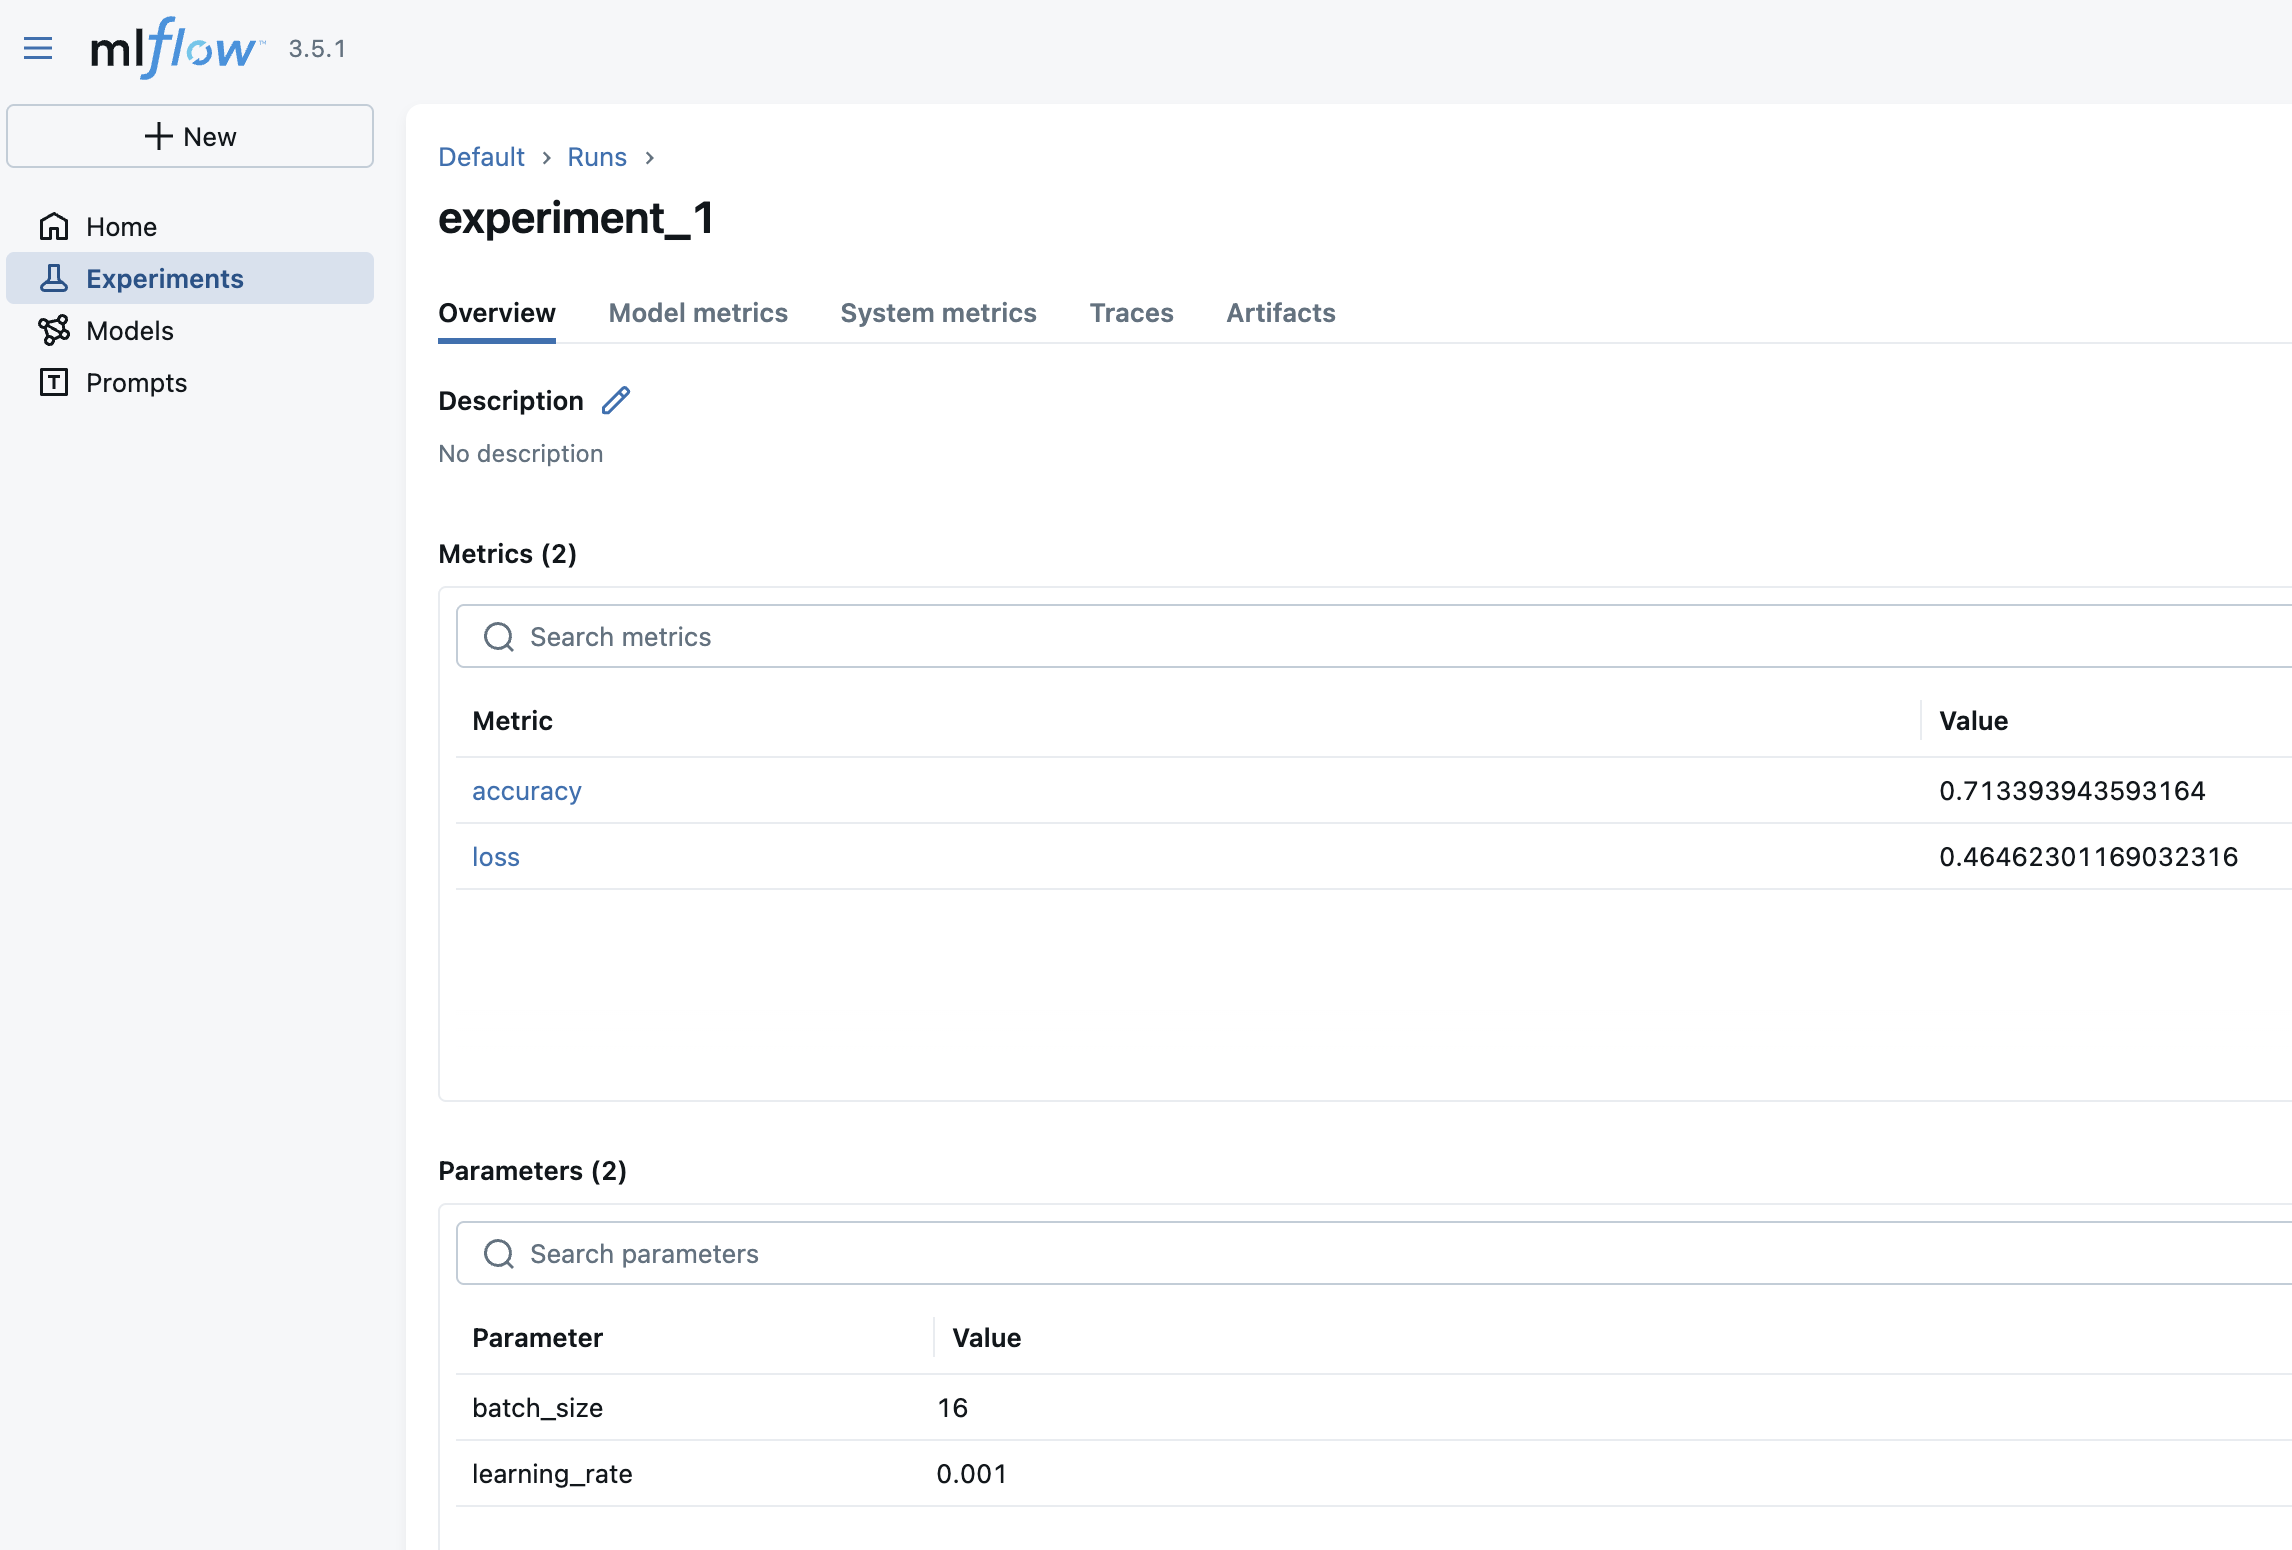

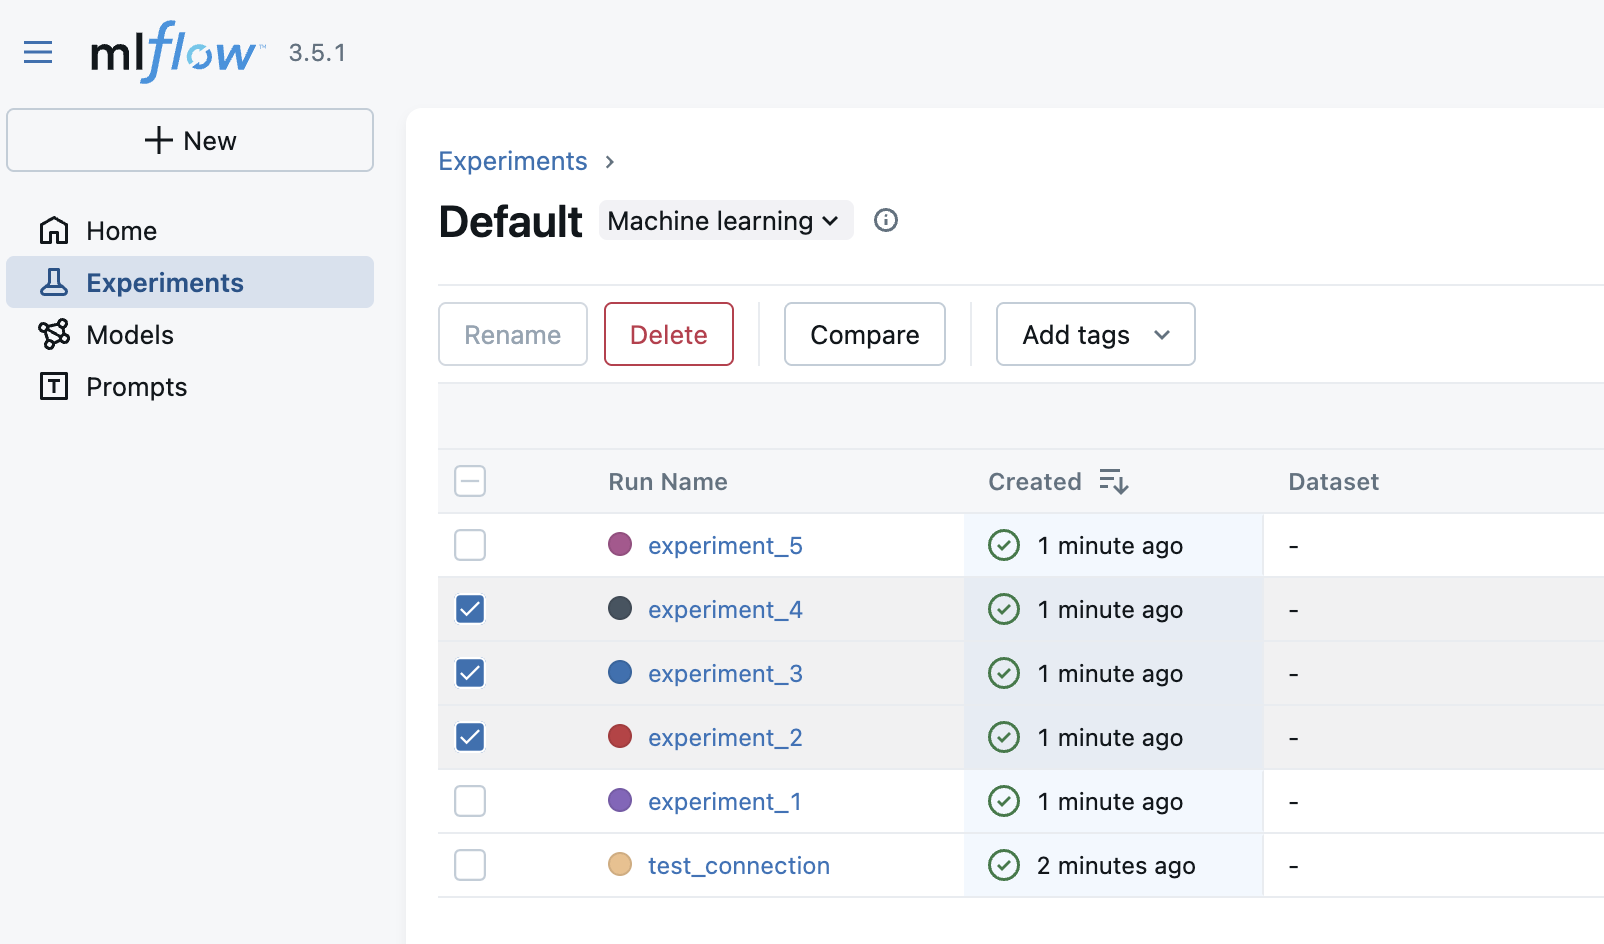

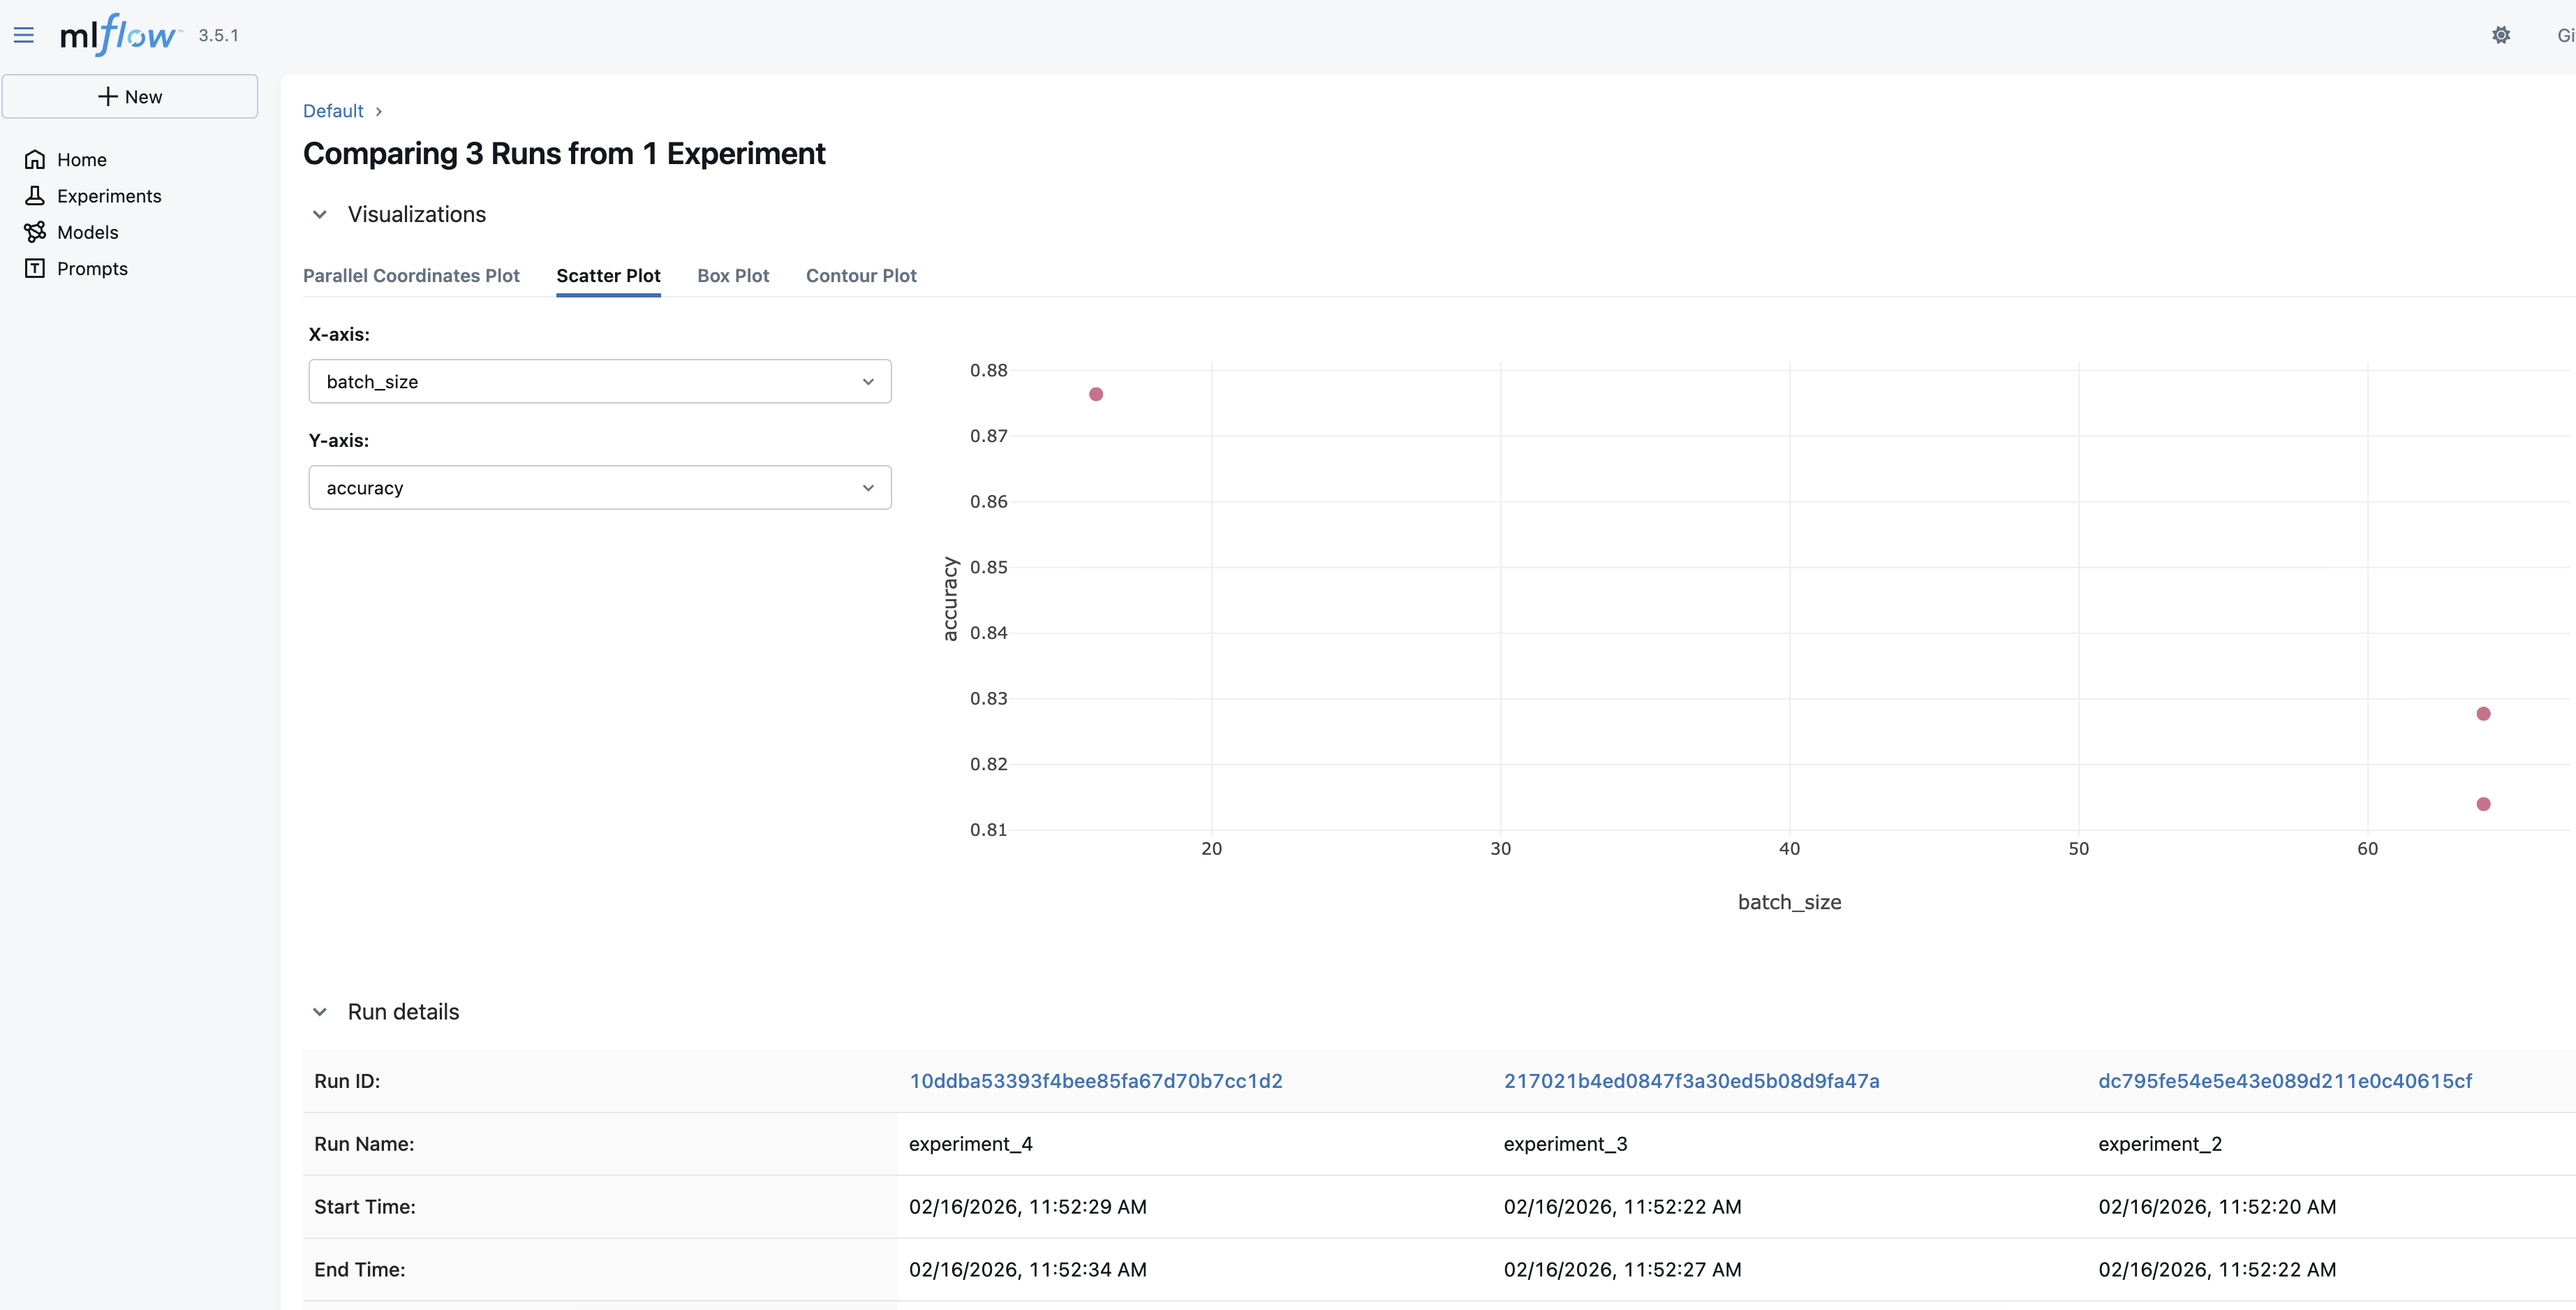

## 4️⃣ Dacon 데이터 다운로드



### Dacon 계정 생성

1. https://dacon.io 접속
2. 회원가입 (카카오/네이버/구글 계정 가능)
3. 로그인

### 데이터 다운로드

1. 대회 페이지 이동: https://dacon.io/competitions/official/235747
2. "데이터" 탭 클릭
3. `train_data.csv`, `test_data.csv`, `topic_dict.csv`, `sample_submission.csv` 다운로드
4. 다운로드한 파일을 아래 셀에서 업로드

#### **방법 1: 직접 업로드 (빠름)**

In [ ]:
import os
import zipfile
from google.colab import files

# 1. 경로 설정
# 최종적으로 데이터가 저장될 하위 폴더 이름은 'dacon_data'로 고정합니다.
base_data_path = '/content/data'
target_path = os.path.join(base_data_path, 'dacon_data')

os.makedirs(target_path, exist_ok=True)

# 2. 파일 업로드
print("📤 업로드할 ZIP 파일을 선택해주세요 (파일명 상관없음)...")
uploaded = files.upload()

# 3. 업로드된 파일 중 ZIP 파일 자동 탐색 및 압축 해제
uploaded_zip_files = [f for f in uploaded.keys() if f.endswith('.zip')]

if uploaded_zip_files:
    # 가장 먼저 업로드된 ZIP 파일 하나를 대상으로 수행
    zip_file_name = uploaded_zip_files[0]

    print(f"\n📦 '{zip_file_name}'을(를) {target_path}에 압축 해제 중...")
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall(target_path)

    print(f"✅ 압축 해제 완료: {target_path}")

    # 세션 용량 확보를 위해 업로드된 원본 zip 파일 삭제
    os.remove(zip_file_name)
else:
    print("\n⚠️ 업로드된 파일 중 ZIP 형식이 없습니다.")

# 4. 결과 확인
print(f"\n📂 {target_path} 내부 파일 목록:")
try:
    print(os.listdir(target_path))
except FileNotFoundError:
    print("폴더가 생성되지 않았습니다.")

📤 업로드할 ZIP 파일을 선택해주세요 (파일명 상관없음)...


Saving open (2).zip to open (2) (1).zip

📦 'open (2) (1).zip'을(를) /content/data/dacon_data에 압축 해제 중...
✅ 압축 해제 완료: /content/data/dacon_data

📂 /content/data/dacon_data 내부 파일 목록:
['sample_submission.csv', 'test_data.csv', 'topic_dict.csv', 'train_data.csv']


In [ ]:
data_path = target_path

In [ ]:
# from google.colab import files

# # 파일 선택 창이 나타납니다
# print("📁 train_data.csv, test_data.csv, topic_dict.csv, sample_submission.csv 파일을 선택하세요")
# uploaded = files.upload()

# print("\n✅ 업로드 완료!")
# for filename in uploaded.keys():
#     print(f"  - {filename}")

#### **방법 2: Google Drive 사용**

만약 Drive에 미리 업로드했다면:

In [ ]:
# import shutil

# # Google Drive에서 복사 (Drive에 업로드했을 경우)
# # drive_data_path = '/content/drive/MyDrive/dacon_data'  # Drive에 업로드한 경로
# drive_data_path = '/content/drive/MyDrive/lectures/dl_bootcamp/day1_news_classification/data/dacon_data'  # Drive에 업로드한 경로

# # 현재 작업 폴더로 복사
# if os.path.exists(f'{drive_data_path}/train_data.csv'):
#     shutil.copy(f'{drive_data_path}/train_data.csv', './train_data.csv')
#     shutil.copy(f'{drive_data_path}/test_data.csv', './test_data.csv')
#     shutil.copy(f'{drive_data_path}/topic_dict.csv', './topic_dict.csv')
#     shutil.copy(f'{drive_data_path}/sample_submission.csv', './sample_submission.csv')
#     print("✅ Drive에서 데이터 복사 완료!")
# else:
#     print("❌ Drive에 데이터가 없습니다. 방법 1을 사용하세요.")

### 데이터 확인

In [ ]:
import pandas as pd

# 데이터 로드
train_df = pd.read_csv(os.path.join(data_path, 'train_data.csv'))
test_df = pd.read_csv(os.path.join(data_path, 'test_data.csv'))

print("✅ 데이터 로드 성공!")
print(f"\n📊 Train 데이터: {len(train_df):,}개")
print(f"📊 Test 데이터: {len(test_df):,}개")

print("\n🔍 Train 데이터 샘플:")
train_df.head()

✅ 데이터 로드 성공!

📊 Train 데이터: 45,654개
📊 Test 데이터: 9,131개

🔍 Train 데이터 샘플:


,index,title,topic_idx
0,0,인천→핀란드 항공기 결항…휴가철 여행객 분통,4
1,1,실리콘밸리 넘어서겠다…구글 15조원 들여 美전역 거점화,4
2,2,이란 외무 긴장완화 해결책은 미국이 경제전쟁 멈추는 것,4
3,3,NYT 클린턴 측근韓기업 특수관계 조명…공과 사 맞물려종합,4
4,4,시진핑 트럼프에 중미 무역협상 조속 타결 희망,4


## ✅ Day 1-1 완료 체크리스트



아래 항목을 모두 완료했는지 확인하세요:

- [ ] GPU 사용 가능 확인 (T4 또는 다른 GPU)
- [ ] Google Drive 연동 완료
- [ ] Dagshub 계정 생성 및 프로젝트 생성
- [ ] MLflow 연동 성공 (6개 테스트 실험 기록)
- [ ] Dagshub UI에서 실험 결과 확인 완료
- [ ] Dacon 데이터 다운로드 및 로드 성공

## 🎉 축하합니다!

환경 설정이 완료되었습니다. 이제 본격적인 딥러닝 실험을 시작할 준비가 되었습니다!



**다음 단계 (Day 1-2)**:
- 뉴스 토픽 분류 문제 이해
- 데이터 EDA (탐색적 데이터 분석)
- TF-IDF + Logistic Regression 베이스라인
- 첫 번째 실전 MLflow 실험 기록

## 🔧 트러블슈팅



### GPU가 할당되지 않았어요
- 런타임 > 런타임 유형 변경 > GPU (T4) 선택
- Colab Pro가 활성화되어 있는지 확인

### Dagshub 연동이 안 돼요
- `repo_owner`와 `repo_name`이 정확한지 확인 (대소문자 구분)
- Dagshub에서 Repository를 Public으로 생성했는지 확인

### 데이터 파일을 못 찾겠어요
- Dacon 로그인 후 데이터 탭에서 다운로드
- 파일 이름이 정확히 `train_data.csv`, `test_data.csv`인지 확인